# ROGII Wellbore Geology Prediction

## Notebook 05 – Machine Learning Model Development

### Objectives

- Build a complete machine-learning training pipeline
- Create row-level features for horizontal-well TVT prediction
- Prepare the feature matrix and target variable
- Apply well-based validation to prevent data leakage
- Train and compare regression and ensemble models
- Compare machine-learning models against Notebook 04 baselines
- Identify the strongest model for further optimization
- Save reusable datasets, model results, and trained artifacts

### Modelling Principle

All validation splits will be performed at the well level. Rows from the same well must not appear in both the training and validation datasets, because this would produce overly optimistic performance estimates.

### 1. Import Libraries

In [3]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyarrow as pa
import pyarrow.parquet as pq

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### 2. Configure Project Paths

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [5]:
from src.config import *
PROCESSED_DIR
create_project_directories()

In [6]:
print("Project Root:", PROJECT_ROOT)
print("Training Directory:", TRAIN_DIR)
print("Test Directory:", TEST_DIR)
print("Processed Directory:", PROCESSED_DIR)
print("Models Directory:", MODELS_DIR)
print("Results Directory:", RESULTS_DIR)

print("\nTraining directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Project Root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Training Directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\train
Test Directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\test
Processed Directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\processed
Models Directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\models
Results Directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results

Training directory exists: True
Test directory exists: True


### 3. Discover Training Well Pairs

In [7]:
from src.data_loader import discover_training_wells

In [8]:
well_ids = discover_training_wells()

print(f"Complete well pairs found: {len(well_ids)}")
print("First five well IDs:")
print(well_ids[:5])

print("\nLast five well IDs:")
print(well_ids[-5:])

Complete well pairs found: 773
First five well IDs:
['000d7d20', '00bbac68', '00e12e8b', '015fe0d2', '01869cd4']

Last five well IDs:
['febb4411', 'fef8af96', 'ff0aea78', 'ff8bb73a', 'ffefef30']


In [9]:
assert len(well_ids) > 0, "No complete training well pairs were found."
assert len(well_ids) == 773, (
    f"Expected 773 well pairs, but found {len(well_ids)}."
)

print("Training well-pair discovery completed successfully.")

Training well-pair discovery completed successfully.


#### Verify Data Loader Module

The reusable data-loading module is verified by discovering both training and test wells and loading representative datasets. This confirms that the shared data access layer functions correctly before it is reused throughout the remaining notebooks.

In [10]:
from src.data_loader import discover_training_wells

training_wells = discover_training_wells()

print("Training wells:", len(training_wells))

Training wells: 773


### 4. Define Feature Engineering

This section loads the reusable feature engineering definitions from the `src` package. Keeping feature engineering logic inside `src/feature_engineering.py` ensures that the same transformations are applied consistently during training, validation, Kaggle test prediction, and later production use.

#### 4.1 Load Feature Definitions

The feature groups, target column, validation group column, and reusable feature-generation function are imported from the project source package.

In [11]:
from src.feature_engineering import (
    DIRECT_FEATURES,
    COORDINATE_FEATURES,
    FORMATION_MARKER_FEATURES,
    RAW_FEATURES,
    TARGET_COLUMN,
    GROUP_COLUMN,
    create_horizontal_features,
)

In [12]:
print("Number of raw input features:", len(RAW_FEATURES))
print("Target column:", TARGET_COLUMN)
print("Group column:", GROUP_COLUMN)

Number of raw input features: 12
Target column: TVT
Group column: well_id


#### 4.2 Feature Design Strategy

The initial machine-learning dataset uses a controlled set of reliable features before introducing more complex rolling, window-based, and typewell-relative features.

The feature groups include:

1. **Direct measurement features**
   - `MD`
   - `GR`
   - `TVT_input`

2. **Coordinate features**
   - `X`
   - `Y`
   - `Z`

3. **Formation-marker features**
   - `ANCC`
   - `ASTNU`
   - `ASTNL`
   - `EGFDU`
   - `EGFDL`
   - `BUDA`

The reusable feature engineering function also creates relative-position, coordinate-difference, measurement-difference, horizontal-distance, and spatial-distance features.

The target variable is the actual horizontal-well `TVT`, while `well_id` is used only for grouped validation.

#### 4.3 Validate Feature Generation

Before generating the complete machine-learning dataset, the feature engineering pipeline is validated using a single representative well. This helps identify potential issues early and ensures that the generated features have the expected structure.

In [13]:
from src.data_loader import load_horizontal_well

In [14]:
sample_well = well_ids[0]

horizontal_df = load_horizontal_well(sample_well)

sample_features = create_horizontal_features(
    horizontal_df=horizontal_df,
    well_id=sample_well,
)

print("Sample well:", sample_well)
print("Shape:", sample_features.shape)

sample_features.head()

Sample well: 000d7d20
Shape: (5278, 26)


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id,MD_relative,X_relative,Y_relative,Z_relative,MD_diff,X_diff,Y_diff,Z_diff,GR_diff,TVT_input_diff,horizontal_distance,spatial_distance
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20,1.0,0.02,0.21,-0.98,1.0,0.02,0.21,-0.98,-0.108293,1.03,0.210950,1.002447
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20,2.0,0.04,0.43,-1.95,1.0,0.02,0.22,-0.97,19.862666,1.04,0.431856,1.997248
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20,3.0,0.06,0.64,-2.93,1.0,0.02,0.21,-0.98,4.954386,1.03,0.642806,2.999683
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20,4.0,0.09,0.86,-3.90,1.0,0.03,0.22,-0.97,-29.130707,1.03,0.864696,3.994709


In [15]:
sample_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 5278 entries, 0 to 5277
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MD                   5278 non-null   float64
 1   X                    5278 non-null   float64
 2   Y                    5278 non-null   float64
 3   Z                    5278 non-null   float64
 4   ANCC                 5278 non-null   float64
 5   ASTNU                5278 non-null   float64
 6   ASTNL                5278 non-null   float64
 7   EGFDU                5278 non-null   float64
 8   EGFDL                5278 non-null   float64
 9   BUDA                 5278 non-null   float64
 10  TVT                  5278 non-null   float64
 11  GR                   3020 non-null   float64
 12  TVT_input            1442 non-null   float64
 13  well_id              5278 non-null   str    
 14  MD_relative          5278 non-null   float64
 15  X_relative           5278 non-null   float64
 16 

In [16]:
sample_features.describe().T

,count,mean,std,min,25%,50%,75%,max
MD,5278.0,1.410550e+04,1523.771691,1.146700e+04,1.278625e+04,1.410550e+04,1.542475e+04,1.674400e+04
X,5278.0,2.983514e+06,29.973792,2.983468e+06,2.983487e+06,2.983514e+06,2.983535e+06,2.983578e+06
Y,5278.0,1.071418e+06,1503.381456,1.069022e+06,1.070090e+06,1.071407e+06,1.072723e+06,1.074041e+06
Z,5278.0,-9.673194e+03,80.961903,-9.755610e+03,-9.721763e+03,-9.689230e+03,-9.650035e+03,-9.258570e+03
ANCC,5278.0,-9.330622e+03,35.272977,-9.395810e+03,-9.362307e+03,-9.335975e+03,-9.296665e+03,-9.271000e+03
ASTNU,5278.0,-9.504672e+03,35.272977,-9.569860e+03,-9.536358e+03,-9.510025e+03,-9.470715e+03,-9.445050e+03
ASTNL,5278.0,-9.532452e+03,35.272977,-9.597640e+03,-9.564137e+03,-9.537805e+03,-9.498495e+03,-9.472830e+03
EGFDU,5278.0,-9.605802e+03,35.272977,-9.670990e+03,-9.637487e+03,-9.611155e+03,-9.571845e+03,-9.546180e+03
EGFDL,5278.0,-9.640772e+03,35.272977,-9.705960e+03,-9.672458e+03,-9.646125e+03,-9.606815e+03,-9.581150e+03
BUDA,5278.0,-9.781162e+03,35.272977,-9.846350e+03,-9.812847e+03,-9.786515e+03,-9.747205e+03,-9.721540e+03


### 5. Build the Machine Learning Dataset

The feature engineering function is now applied to every training well. Each row of every horizontal well becomes one machine-learning sample, producing a single dataset suitable for supervised regression.

In [17]:
all_feature_frames = []

for well_id in well_ids:

    horizontal_df = pd.read_csv(
        TRAIN_DIR / f"{well_id}__horizontal_well.csv"
    )

    feature_df = create_horizontal_features(
        horizontal_df,
        well_id
    )

    all_feature_frames.append(feature_df)

print(f"Processed {len(all_feature_frames)} wells.")

Processed 773 wells.


In [18]:
ml_dataset = pd.concat(
    all_feature_frames,
    ignore_index=True
)

print("Dataset created successfully.")

Dataset created successfully.


In [19]:
print("Dataset shape:")
print(ml_dataset.shape)

ml_dataset.head()

Dataset shape:
(5092255, 26)


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id,MD_relative,X_relative,Y_relative,Z_relative,MD_diff,X_diff,Y_diff,Z_diff,GR_diff,TVT_input_diff,horizontal_distance,spatial_distance
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20,1.0,0.02,0.21,-0.98,1.0,0.02,0.21,-0.98,-0.108293,1.03,0.210950,1.002447
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20,2.0,0.04,0.43,-1.95,1.0,0.02,0.22,-0.97,19.862666,1.04,0.431856,1.997248
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20,3.0,0.06,0.64,-2.93,1.0,0.02,0.21,-0.98,4.954386,1.03,0.642806,2.999683
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20,4.0,0.09,0.86,-3.90,1.0,0.03,0.22,-0.97,-29.130707,1.03,0.864696,3.994709


### 6. Inspect and Validate the Dataset

Before model training, the complete machine-learning dataset is inspected to verify its size, feature availability, missing values, and data quality.

In [20]:
print("Rows:", len(ml_dataset))
print("Columns:", ml_dataset.shape[1])

print("\nUnique wells:")
print(ml_dataset["well_id"].nunique())

Rows: 5092255
Columns: 26

Unique wells:
773


In [21]:
ml_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5092255 entries, 0 to 5092254
Data columns (total 26 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MD                   float64
 1   X                    float64
 2   Y                    float64
 3   Z                    float64
 4   ANCC                 float64
 5   ASTNU                float64
 6   ASTNL                float64
 7   EGFDU                float64
 8   EGFDL                float64
 9   BUDA                 float64
 10  TVT                  float64
 11  GR                   float64
 12  TVT_input            float64
 13  well_id              str    
 14  MD_relative          float64
 15  X_relative           float64
 16  Y_relative           float64
 17  Z_relative           float64
 18  MD_diff              float64
 19  X_diff               float64
 20  Y_diff               float64
 21  Z_diff               float64
 22  GR_diff              float64
 23  TVT_input_diff       float64
 24  horizonta

In [22]:
missing = (
    ml_dataset
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

TVT_input_diff    3784762
TVT_input         3783989
GR_diff           2324687
GR                1507972
ANCC                45634
EGFDL                6067
Z_diff                773
Y_diff                773
MD_diff               773
X_diff                773
dtype: int64

In [23]:
ml_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
MD,5092255.0,1.431686e+04,2206.523850,9.335000e+03,1.254700e+04,1.419900e+04,1.592800e+04,2.296400e+04
X,5092255.0,2.965999e+06,47749.981497,2.855426e+06,2.917842e+06,2.986284e+06,3.006569e+06,3.039107e+06
Y,5092255.0,1.074748e+06,35603.540240,1.007176e+06,1.040716e+06,1.080803e+06,1.105967e+06,1.141858e+06
Z,5092255.0,-9.390812e+03,634.475915,-1.102765e+04,-9.920910e+03,-9.270310e+03,-8.918930e+03,-7.174220e+03
ANCC,5046621.0,-9.008724e+03,637.622279,-1.064731e+04,-9.548060e+03,-8.865570e+03,-8.511810e+03,-7.301760e+03
ASTNU,5092255.0,-9.192691e+03,641.864443,-1.085279e+04,-9.723750e+03,-9.063210e+03,-8.691070e+03,-7.509200e+03
ASTNL,5092255.0,-9.257051e+03,626.879708,-1.086558e+04,-9.771820e+03,-9.134010e+03,-8.765320e+03,-7.614430e+03
EGFDU,5092255.0,-9.350495e+03,621.995283,-1.088758e+04,-9.883505e+03,-9.213220e+03,-8.860120e+03,-7.704030e+03
EGFDL,5086188.0,-9.392205e+03,622.220203,-1.093235e+04,-9.925562e+03,-9.256610e+03,-8.902370e+03,-7.731610e+03
BUDA,5092255.0,-9.516918e+03,636.402653,-1.110473e+04,-1.005426e+04,-9.377050e+03,-9.017110e+03,-7.835570e+03


### 7. Define Features, Target, and Well Groups

The machine-learning dataset is separated into predictor variables, the target variable, and well identifiers for grouped cross-validation.

In [24]:
EXCLUDED_COLUMNS = [
    "TVT",
    "well_id"
]

In [25]:
FEATURE_COLUMNS = [
    column
    for column in ml_dataset.columns
    if column not in EXCLUDED_COLUMNS
]

In [26]:
X = ml_dataset[FEATURE_COLUMNS]

y = ml_dataset["TVT"]

groups = ml_dataset["well_id"]

In [27]:
print("Number of features:", len(FEATURE_COLUMNS))
print("Feature matrix:", X.shape)
print("Target:", y.shape)
print("Groups:", groups.nunique())

Number of features: 24
Feature matrix: (5092255, 24)
Target: (5092255,)
Groups: 773


### 8. Prepare Well-Based Cross Validation

Model performance will be evaluated using GroupKFold, ensuring that all rows belonging to the same well remain together in either the training or validation set. This prevents information leakage and better reflects the competition scenario.

In [28]:
group_kfold = GroupKFold(
    n_splits=5
)

In [29]:
for fold, (train_idx, valid_idx) in enumerate(
    group_kfold.split(X, y, groups),
    start=1
):

    train_wells = groups.iloc[train_idx].nunique()
    valid_wells = groups.iloc[valid_idx].nunique()

    print(
        f"Fold {fold}: "
        f"{train_wells} training wells | "
        f"{valid_wells} validation wells"
    )

Fold 1: 619 training wells | 154 validation wells
Fold 2: 619 training wells | 154 validation wells
Fold 3: 618 training wells | 155 validation wells
Fold 4: 618 training wells | 155 validation wells
Fold 5: 618 training wells | 155 validation wells


### 9. Create Machine Learning Pipelines

Before training any models, reusable preprocessing pipelines are created. These pipelines ensure that the same data preparation steps are applied consistently during both training and prediction.

The preprocessing stage handles missing values and feature scaling where appropriate. Wrapping preprocessing and modelling into a single pipeline also prevents data leakage during cross-validation.

In [119]:
from src.models import (
    create_linear_regression_pipeline,
    create_random_forest_pipeline,
)

#### 9.1 Create the pipelines

In [120]:
linear_pipeline = create_linear_regression_pipeline(
    FEATURE_COLUMNS
)

random_forest_pipeline = create_random_forest_pipeline(
    FEATURE_COLUMNS
)

#### 9.2 Verify Pipelines

In [121]:
print("Linear Regression Pipeline")
print(linear_pipeline)

print("\nRandom Forest Pipeline")
print(random_forest_pipeline)

Linear Regression Pipeline
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MD', 'X', 'Y', 'Z', 'ANCC',
                                                   'ASTNU', 'ASTNL', 'EGFDU',
                                                   'EGFDL', 'BUDA', 'GR',
                                                   'TVT_input', 'MD_relative',
                                                   'X_relative', 'Y_relative',
                                                   'Z_relative', 'MD_diff',
                                                   'X_diff', 'Y_diff

### 10. Create the Cross-Validation Evaluation Function

This section defines a reusable evaluation function for machine-learning models.

The function performs GroupKFold cross-validation to ensure that each validation fold contains entirely unseen wells. For every fold, the model is trained, predictions are generated, and regression performance metrics are calculated.

Using a single reusable evaluation function ensures that every machine-learning model is assessed using exactly the same validation procedure, making model comparisons fair and reproducible.

In [122]:
from src.evaluation import (
    calculate_well_level_metrics,
    evaluate_model,
)

print("Evaluation utilities loaded successfully.")

Evaluation utilities loaded successfully.


### 11. Train and Evaluate the Linear Regression Model

Linear Regression is used as the first machine-learning model because it provides a simple and interpretable baseline. Although the relationship between the input features and TVT is expected to be non-linear, Linear Regression establishes a useful benchmark against which more advanced ensemble methods can be compared.

The model is evaluated using the GroupKFold validation strategy defined earlier, ensuring that the validation wells remain unseen during training.

#### 11.1 Train the Model

In [123]:
linear_results, linear_predictions = evaluate_model(
    pipeline=linear_pipeline,
    X=X,
    y=y,
    groups=groups,
    cv=group_kfold
)

Fold 1 | RMSE = 132.57 | MAE = 82.71
Fold 2 | RMSE = 120.23 | MAE = 92.03
Fold 3 | RMSE = 97.61 | MAE = 76.24
Fold 4 | RMSE = 113.39 | MAE = 83.63
Fold 5 | RMSE = 111.61 | MAE = 84.60


#### 11.2 View Fold Results

In [36]:
linear_results

,fold,rmse,mae
0,1,132.573164,82.713978
1,2,120.232945,92.029001
2,3,97.611626,76.241465
3,4,113.387369,83.633302
4,5,111.614451,84.595229


#### 11.3 Average Performance

In [37]:
linear_summary = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Mean RMSE": [linear_results["rmse"].mean()],
    "Std RMSE": [linear_results["rmse"].std()],
    "Mean MAE": [linear_results["mae"].mean()],
    "Std MAE": [linear_results["mae"].std()],
})

linear_summary

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE
0,Linear Regression,115.083911,12.772849,83.842595,5.627576


#### 11.4 Visualize Fold Performance

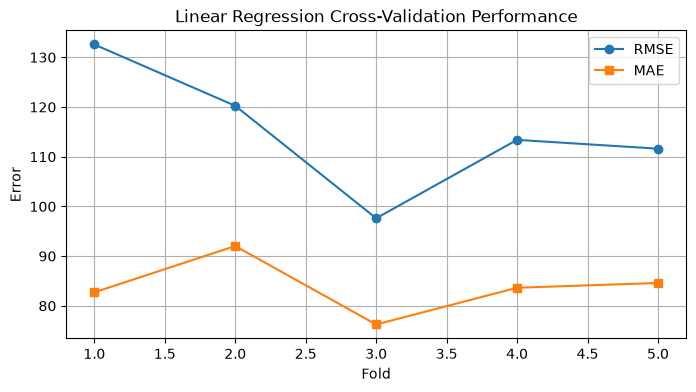

In [38]:
plt.figure(figsize=(8, 4))

plt.plot(
    linear_results["fold"],
    linear_results["rmse"],
    marker="o",
    label="RMSE"
)

plt.plot(
    linear_results["fold"],
    linear_results["mae"],
    marker="s",
    label="MAE"
)

plt.xlabel("Fold")
plt.ylabel("Error")
plt.title("Linear Regression Cross-Validation Performance")

plt.grid(True)
plt.legend()

plt.show()

#### 11.5 Inspect Predictions

In [39]:
linear_predictions.head()

,fold,well_id,actual_tvt,predicted_tvt
0,1,015fe0d2,11747.26,11643.817300
1,1,015fe0d2,11748.21,11676.591786
2,1,015fe0d2,11749.16,11677.622139
3,1,015fe0d2,11750.12,11677.972816
4,1,015fe0d2,11751.07,11678.044121


#### 11.6 Actual vs Predicted Scatter Plot

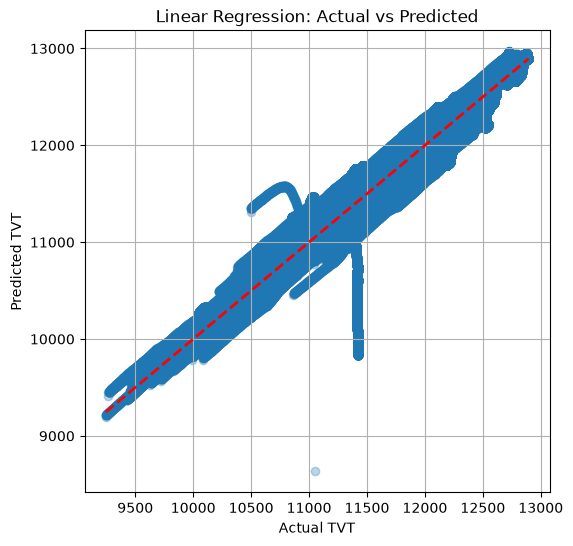

In [40]:
plt.figure(figsize=(6, 6))

plt.scatter(
    linear_predictions["actual_tvt"],
    linear_predictions["predicted_tvt"],
    alpha=0.3
)

min_val = linear_predictions["actual_tvt"].min()
max_val = linear_predictions["actual_tvt"].max()

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2
)

plt.xlabel("Actual TVT")
plt.ylabel("Predicted TVT")
plt.title("Linear Regression: Actual vs Predicted")

plt.grid(True)
plt.show()

### 12. Train and Evaluate the Random Forest Model

Random Forest is an ensemble learning method that combines many decision trees. Unlike Linear Regression, it can capture nonlinear relationships and interactions between trajectory, geological, spatial, and formation-marker features.

The model is evaluated using the same GroupKFold validation strategy to ensure a fair comparison with Linear Regression.

#### 12.1 Run cross-validation

In [41]:
random_forest_results, random_forest_predictions = evaluate_model(
    pipeline=random_forest_pipeline,
    X=X,
    y=y,
    groups=groups,
    cv=group_kfold
)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.4min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  8.1min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    1.8s finished


Fold 1 | RMSE = 88.76 | MAE = 43.02


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.6min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  8.3min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.0s finished


Fold 2 | RMSE = 107.89 | MAE = 47.93


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.7min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  8.8min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.2s finished


Fold 3 | RMSE = 91.54 | MAE = 47.65


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  4.0min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  9.2min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.9s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.2s finished


Fold 4 | RMSE = 134.04 | MAE = 56.11


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  3.9min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:  8.9min finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.8s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    2.0s finished


Fold 5 | RMSE = 96.20 | MAE = 47.83


#### 12.2 View fold results

In [42]:
random_forest_results

,fold,rmse,mae
0,1,88.758457,43.016562
1,2,107.894339,47.932604
2,3,91.538003,47.647772
3,4,134.044673,56.113260
4,5,96.197374,47.828133


#### 12.3 Create summary

In [43]:
random_forest_summary = pd.DataFrame({
    "Model": ["Random Forest"],
    "Mean RMSE": [random_forest_results["rmse"].mean()],
    "Std RMSE": [random_forest_results["rmse"].std()],
    "Mean MAE": [random_forest_results["mae"].mean()],
    "Std MAE": [random_forest_results["mae"].std()],
})

random_forest_summary

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE
0,Random Forest,103.686569,18.478664,48.507666,4.730993


#### 12.4 Plot fold performance

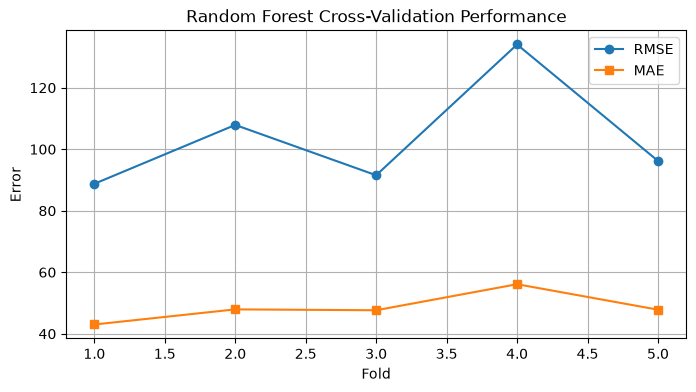

In [44]:
plt.figure(figsize=(8, 4))

plt.plot(
    random_forest_results["fold"],
    random_forest_results["rmse"],
    marker="o",
    label="RMSE"
)

plt.plot(
    random_forest_results["fold"],
    random_forest_results["mae"],
    marker="s",
    label="MAE"
)

plt.xlabel("Fold")
plt.ylabel("Error")
plt.title("Random Forest Cross-Validation Performance")
plt.grid(True)
plt.legend()
plt.show()

#### 12.5 Actual vs Predicted Scatter Plot

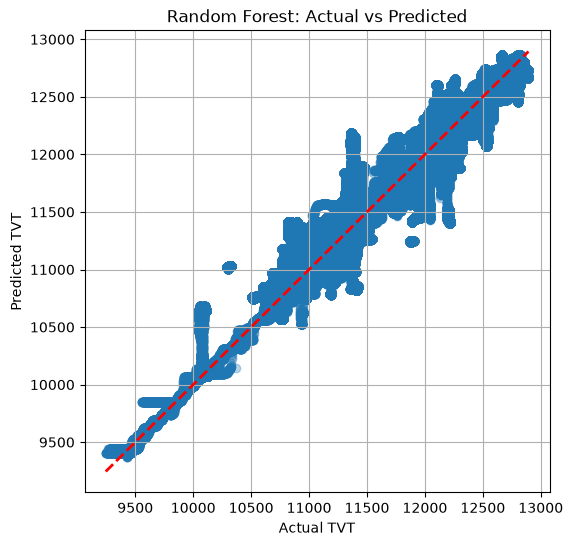

In [45]:
plt.figure(figsize=(6, 6))

plt.scatter(
    random_forest_predictions["actual_tvt"],
    random_forest_predictions["predicted_tvt"],
    alpha=0.3
)

min_val = random_forest_predictions["actual_tvt"].min()
max_val = random_forest_predictions["actual_tvt"].max()

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2
)

plt.xlabel("Actual TVT")
plt.ylabel("Predicted TVT")
plt.title("Random Forest: Actual vs Predicted")

plt.grid(True)
plt.show()

### 13. Compare Initial Machine-Learning Models

This section compares Linear Regression and Random Forest using their mean cross-validation RMSE and MAE.

Because both models were evaluated using identical well-based folds, their results can be compared directly. Lower RMSE and MAE values indicate better predictive performance.

#### 13.1 Combine summaries

In [46]:
model_comparison = pd.concat(
    [
        linear_summary,
        random_forest_summary
    ],
    ignore_index=True
)

model_comparison = model_comparison.sort_values(
    "Mean RMSE"
).reset_index(drop=True)

model_comparison

,Model,Mean RMSE,Std RMSE,Mean MAE,Std MAE
0,Random Forest,103.686569,18.478664,48.507666,4.730993
1,Linear Regression,115.083911,12.772849,83.842595,5.627576


#### 13.2 Identify the best model

In [47]:
best_initial_model = model_comparison.iloc[0]

print("Best initial model:", best_initial_model["Model"])
print(f"Mean RMSE: {best_initial_model['Mean RMSE']:.4f}")
print(f"Mean MAE: {best_initial_model['Mean MAE']:.4f}")

Best initial model: Random Forest
Mean RMSE: 103.6866
Mean MAE: 48.5077


#### 13.3 Visual comparison

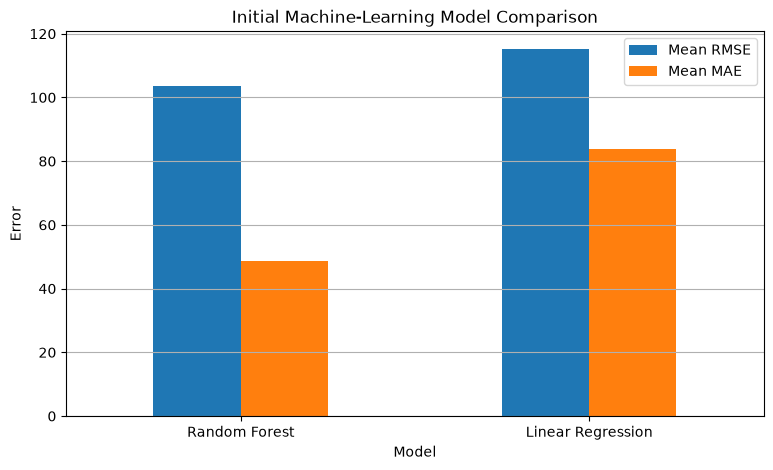

In [48]:
plot_data = model_comparison.set_index("Model")

plot_data[["Mean RMSE", "Mean MAE"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.ylabel("Error")
plt.title("Initial Machine-Learning Model Comparison")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

#### 13.4 Compare improvement

In [49]:
linear_rmse = linear_summary.loc[0, "Mean RMSE"]
rf_rmse = random_forest_summary.loc[0, "Mean RMSE"]

rmse_improvement = linear_rmse - rf_rmse
percentage_improvement = (
    rmse_improvement / linear_rmse
) * 100

print(f"RMSE difference: {rmse_improvement:.4f}")
print(
    f"Random Forest RMSE improvement over Linear Regression: "
    f"{percentage_improvement:.2f}%"
)

RMSE difference: 11.3973
Random Forest RMSE improvement over Linear Regression: 9.90%


### 14. Perform Well-Level Error Analysis

Overall cross-validation metrics can hide large differences between individual wells. This section calculates RMSE and MAE separately for every validation well.

Well-level evaluation helps identify easy, average, and difficult wells and determines whether the machine-learning models improve consistently or only perform well on a limited subset of the dataset.

#### 14.1 Calculate results for both models

In [51]:
linear_well_results = calculate_well_level_metrics(
    linear_predictions,
    "Linear Regression"
)

random_forest_well_results = calculate_well_level_metrics(
    random_forest_predictions,
    "Random Forest"
)

well_level_results = pd.concat(
    [
        linear_well_results,
        random_forest_well_results
    ],
    ignore_index=True
)

well_level_results.head()

,well_id,model,rmse,mae,n_rows
0,000d7d20,Linear Regression,247.780974,247.684869,5278
1,00bbac68,Linear Regression,38.176813,36.255912,7559
2,00e12e8b,Linear Regression,83.524602,82.544178,6384
3,015fe0d2,Linear Regression,101.558026,99.531361,5950
4,01869cd4,Linear Regression,80.903689,80.624066,6850


#### 14.2 Summarize well-level performance

In [52]:
well_level_summary = (
    well_level_results
    .groupby("model")
    .agg(
        mean_well_rmse=("rmse", "mean"),
        median_well_rmse=("rmse", "median"),
        worst_well_rmse=("rmse", "max"),
        mean_well_mae=("mae", "mean"),
        median_well_mae=("mae", "median")
    )
    .reset_index()
)

well_level_summary

,model,mean_well_rmse,median_well_rmse,worst_well_rmse,mean_well_mae,median_well_mae
0,Linear Regression,87.830913,65.930805,1048.758470,85.577023,63.853001
1,Random Forest,60.971865,31.394283,672.771417,48.302020,22.978489


#### 14.3 Inspect difficult Random Forest wells

In [53]:
random_forest_well_results.sort_values(
    "rmse",
    ascending=False
).head(10)

,well_id,model,rmse,mae,n_rows
604,cbe51de1,Random Forest,672.771417,613.473939,5362
14,059c8f24,Random Forest,635.609166,567.555900,7998
387,877ed19c,Random Forest,603.079215,521.071323,5631
546,b85f7b06,Random Forest,601.084267,531.369728,5453
174,3a7dd95d,Random Forest,543.574723,481.824235,4320
592,c8d9680c,Random Forest,502.810813,450.829649,7741
686,e730c32b,Random Forest,485.869160,458.964972,6469
605,cbe62450,Random Forest,440.590525,374.959898,7858
602,cb879f40,Random Forest,433.784433,364.314442,7904
459,9c350a6a,Random Forest,425.762616,406.972270,7794


#### 14.4 Plot RMSE distribution

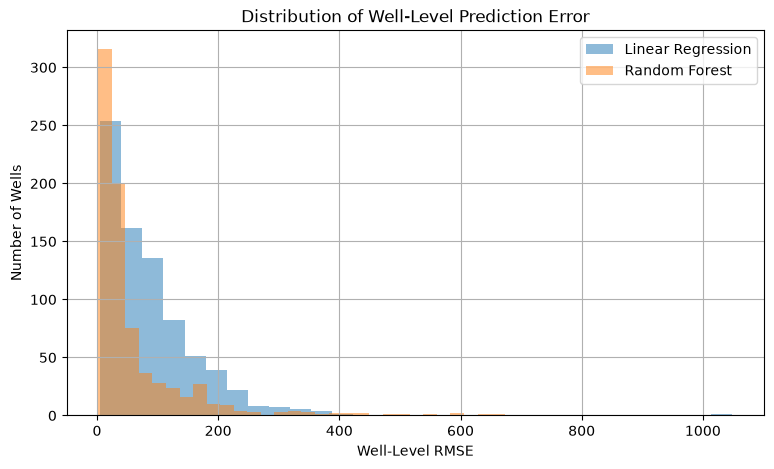

In [54]:
plt.figure(figsize=(9, 5))

for model_name, model_df in well_level_results.groupby("model"):
    plt.hist(
        model_df["rmse"],
        bins=30,
        alpha=0.5,
        label=model_name
    )

plt.xlabel("Well-Level RMSE")
plt.ylabel("Number of Wells")
plt.title("Distribution of Well-Level Prediction Error")
plt.legend()
plt.grid(True)
plt.show()

### 15. Save Processed Machine Learning Dataset

The fully engineered machine learning dataset is saved to the `data/processed`
directory. This enables future notebooks to reuse the prepared dataset without
repeating the expensive feature engineering process.

In [30]:
ML_DATASET_PATH = PROCESSED_DIR / "ml_dataset.parquet"

ml_dataset.to_parquet(
    ML_DATASET_PATH,
    index=False
)

print(f"Saved processed dataset to: {ML_DATASET_PATH}")
print(f"Dataset shape: {ml_dataset.shape}")
print(
    f"File size (MB): "
    f"{ML_DATASET_PATH.stat().st_size / (1024 ** 2):.1f}"
)

Saved processed dataset to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\processed\ml_dataset.parquet
Dataset shape: (5092255, 26)
File size (MB): 428.5


### 16. Save Results and Trained Models

This section saves the evaluation results, trained machine-learning models, and feature definitions generated throughout Notebook 05.

These outputs will be reused in later notebooks for model optimisation and will also support the final production application.

#### 16.1 Train Final Models on All Training Wells

In [56]:
final_linear_model = clone(linear_pipeline)
final_linear_model.fit(X, y)

final_random_forest_model = clone(random_forest_pipeline)
final_random_forest_model.fit(X, y)

print("Final models trained successfully.")

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  4.1min


Final models trained successfully.


[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed: 10.4min finished


#### 16.2 Save Models

In [69]:
joblib.dump(
    final_linear_model,
    NOTEBOOK_05_MODELS_DIR / "linear_regression_model.joblib"
)

joblib.dump(
    final_random_forest_model,
    NOTEBOOK_05_MODELS_DIR / "random_forest_model.joblib"
)

print(f"Models saved to: {NOTEBOOK_05_MODELS_DIR}")

Models saved to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\models\notebook_05


#### 16.3 Save Results

In [60]:
NOTEBOOK_RESULTS_DIR = RESULTS_DIR / "notebook_05"
NOTEBOOK_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [61]:
model_comparison.to_csv(
    NOTEBOOK_RESULTS_DIR / "model_comparison.csv",
    index=False
)

well_level_results.to_csv(
    NOTEBOOK_RESULTS_DIR / "well_level_results.csv",
    index=False
)

linear_predictions.to_csv(
    NOTEBOOK_RESULTS_DIR / "linear_regression_predictions.csv",
    index=False
)

random_forest_predictions.to_csv(
    NOTEBOOK_RESULTS_DIR / "random_forest_predictions.csv",
    index=False
)

print(f"Notebook 05 results saved to: {NOTEBOOK_RESULTS_DIR}")

Notebook 05 results saved to: ..\results\notebook_05


#### 16.4 Save Feature List

In [70]:
with open(
    NOTEBOOK_05_MODELS_DIR / "feature_columns.json",
    "w"
) as f:
    json.dump(
        FEATURE_COLUMNS,
        f,
        indent=4
    )

### 17. Conclusion

#### 17.1 Notebook Summary

This notebook built the first machine-learning pipeline for row-level TVT prediction on the ROGII wellbore geology dataset. Feature engineering was applied consistently across all **773** complete training well pairs, producing a modelling dataset of **5,092,255** rows and **24** predictor features spanning direct measurements, trajectory/spatial geometry, formation markers, and simple derived differences.

Models were evaluated with **GroupKFold** (5 folds, ~154–155 validation wells each) so that no well appeared in both training and validation. Two models were compared under identical folds and preprocessing: **Linear Regression** (scaled linear baseline) and **Random Forest** (nonlinear ensemble). Fold summaries, well-level error statistics, trained pipelines, and prediction files were saved under `results/notebook_05/` and `models/`.

#### 17.2 Key Findings

**Random Forest is the stronger initial model.** On mean cross-validation metrics, Random Forest outperformed Linear Regression:

| Model | Mean RMSE | Std RMSE | Mean MAE | Std MAE |
|---|---:|---:|---:|---:|
| Random Forest | **103.69** | 18.48 | **48.51** | 4.73 |
| Linear Regression | 115.08 | 12.77 | 83.84 | 5.63 |

RMSE improved by about **9.9%** (~11.4 absolute). MAE improved far more (**~42%**), showing that Random Forest reduces typical point errors substantially, while a smaller set of large mistakes still limits RMSE.

**Nonlinear structure matters.** Linear Regression established a useful benchmark, but the TVT–feature relationship is clearly nonlinear. Random Forest’s gains confirm that trajectory, formation-marker, and spatial interactions are better captured by tree ensembles than by a single global linear map.

**Well-level performance is highly skewed.** Aggregate fold metrics hide large between-well differences:

| Model | Mean well RMSE | Median well RMSE | Worst well RMSE | Median well MAE |
|---|---:|---:|---:|---:|
| Linear Regression | 87.83 | 65.93 | 1048.76 | 63.85 |
| Random Forest | **60.97** | **31.39** | **672.77** | **22.98** |

For Random Forest, median well RMSE (~**31**) is much lower than mean well RMSE (~**61**), and a few wells dominate error (worst cases above **600** RMSE, e.g. `cbe51de1`, `059c8f24`, `877ed19c`, `b85f7b06`, `3a7dd95d`). Improving difficult wells is therefore a higher-leverage next step than chasing small average gains on easy wells.

**Validation discipline is working as intended.** Keeping all rows of a well together in GroupKFold prevents optimistic leakage and better matches the competition setting of predicting on entirely unseen wells.

#### 17.3 Limitations of the Current Models

- **Initial feature set only.** Rolling statistics, distance-to-marker features, typewell-relative matching, and richer window-based geological signals were deferred by design.
- **No hyperparameter optimization.** Random Forest used a fixed configuration (`n_estimators=100`, `max_depth=18`, `min_samples_leaf=50`, `max_samples=0.10`) chosen for tractability on a multi-million-row dataset, not for peak accuracy.
- **Large residual tails.** Fold RMSE standard deviation and worst-well RMSE remain high, so average metrics overstate reliability on hard wells.
- **No formal head-to-head vs Notebook 04 hidden-section scores.** Notebook 04 baselines (especially Last Known TVT) were scored only on rows where `TVT_input` is missing. This notebook’s ML metrics cover full validation wells, so the numbers are not directly interchangeable; a masked, hidden-section comparison remains useful future work.

#### 17.4 Implications for Next Steps

Random Forest should be the default model for further optimization. Priority directions:

1. **Enrich features** with typewell relationships, marker distances, and local geological/rolling context, especially for high-error wells.
2. **Tune or replace the ensemble** (deeper Random Forest search, then gradient boosting such as XGBoost/LightGBM).
3. **Diagnose difficult wells** separately—error is concentrated, so targeted features or residual models may help more than global retraining alone.
4. **Align evaluation with the competition target** by also reporting metrics on the hidden section (`TVT_input` missing) for a fair comparison to Notebook 04 baselines.

Overall, Notebook 05 shows that a well-grouped machine-learning pipeline with a modest initial feature set already beats a linear baseline, with Random Forest as the clear candidate for further optimization.